# Klasifikasi Rimpang — Percobaan 3 (P3): Gaussian Blur + CLAHE

**Preprocessing yang digunakan:**
1. **Resize** — Mengubah ukuran gambar menjadi 128x128 piksel
2. **Grayscale** — Konversi dari citra BGR ke grayscale menggunakan rumus luminance
3. **Gaussian Blur** — Penghalusan citra dengan kernel Gaussian (kernel_size=5, sigma=1)
4. **CLAHE** *(Contrast Limited Adaptive Histogram Equalization)* — Peningkatan kontras adaptif (clip_limit=2.0, tile_size=8)

---

### Mengapa Percobaan 3 (P3) Dilakukan?

Pada percobaan sebelumnya, preprocessing yang digunakan belum optimal dalam menangani dua masalah utama pada citra rimpang, yaitu **noise** dan **variasi pencahayaan** yang tidak konsisten. Percobaan P3 ini dirancang untuk mengatasi kedua masalah tersebut secara berurutan:

- **Gaussian Blur** diterapkan terlebih dahulu untuk **mereduksi noise** pada citra. Noise berupa variasi piksel acak dapat mengganggu proses ekstraksi fitur GLCM karena menghasilkan tekstur palsu (artifak) yang tidak merepresentasikan tekstur asli rimpang. Dengan menghaluskan citra terlebih dahulu, fitur tekstur yang diekstrak akan lebih bersih dan representatif.

- **CLAHE** kemudian diterapkan setelah blur untuk **meningkatkan kontras secara adaptif**. Berbeda dengan histogram equalization biasa yang menerapkan transformasi secara global, CLAHE membagi citra menjadi tile-tile kecil dan melakukan equalisasi secara lokal pada setiap tile. Ini menjaga detail lokal tetap terlihat jelas meskipun pencahayaan antar-bagian citra tidak merata. Hal ini sangat penting untuk citra rimpang yang sering difoto dalam kondisi pencahayaan yang berbeda-beda.

Kombinasi **Blur kemudian CLAHE** ini diharapkan menghasilkan citra yang lebih bersih dari noise namun tetap memiliki kontras tekstur yang kuat, sehingga fitur GLCM yang diekstrak menjadi lebih diskriminatif untuk membedakan antara jahe, kunyit, dan lengkuas.

In [1]:
# Cell 1 — Import
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from library import (
    load_images, extract_glcm_features, extract_color_features, extract_lbp_features, evaluate_and_save, preview_preprocessing,
    manual_resize, manual_bgr_to_grayscale, manual_gaussian_blur,
    manual_median_blur, manual_clahe, manual_histogram_equalization,
    manual_erosion, manual_dilation, manual_opening, manual_closing
)

print('Import berhasil')

Import berhasil


### Penjelasan Cell 1 — Import Library

Cell di atas melakukan proses **import** seluruh library dan fungsi yang dibutuhkan dalam eksperimen ini. Berikut penjelasan setiap komponen yang diimpor:

- **NumPy** (numpy): Digunakan untuk operasi array dan matriks numerik, yang merupakan representasi dasar dari citra digital. Setiap gambar direpresentasikan sebagai array NumPy.
- **Pandas** (pandas): Digunakan untuk menyimpan dan mengolah data fitur dalam bentuk DataFrame, serta menyimpan hasil ke file CSV.
- **OS** (os): Digunakan untuk operasi sistem file seperti membaca folder dataset dan membuat direktori output.
- **Scikit-learn**: Menyediakan algoritma machine learning yang digunakan dalam klasifikasi:
  - `train_test_split`: Membagi dataset menjadi data training dan testing.
  - `LabelEncoder`: Mengkonversi label teks (jahe, kunyit, lengkuas) menjadi angka.
  - `KNeighborsClassifier`: Algoritma K-Nearest Neighbors.
  - `SVC`: Algoritma Support Vector Machine.
  - `RandomForestClassifier`: Algoritma Random Forest.
- **Library lokal** (library.py): Berisi fungsi-fungsi preprocessing citra yang diimplementasikan secara manual tanpa menggunakan fungsi bawaan OpenCV, termasuk `manual_resize`, `manual_bgr_to_grayscale`, `manual_gaussian_blur`, `manual_clahe`, serta fungsi utilitas seperti `load_images`, `extract_glcm_features`, `evaluate_and_save`, dan `preview_preprocessing`.

In [2]:
# Cell 2 — Konfigurasi
# ⚠️ GANTI INI sesuai eksperimenmu
EXP_NAME = 'P3_Blur_CLAHE'

### Penjelasan Cell 2 — Konfigurasi Eksperimen

Cell di atas mendefinisikan **nama eksperimen** melalui variabel `EXP_NAME` yang diset menjadi `'P3_Blur_CLAHE'`. Nama ini menunjukkan bahwa eksperimen ini adalah **Percobaan ke-3** dengan teknik preprocessing **Gaussian Blur** diikuti oleh **CLAHE**.

Variabel `EXP_NAME` digunakan di seluruh notebook untuk:
- Memberi label pada file output (CSV hasil fitur dan hasil evaluasi)
- Memberi nama pada file gambar confusion matrix
- Memberi judul pada plot visualisasi
- Memudahkan identifikasi hasil saat membandingkan dengan percobaan lain

In [3]:
# Cell 3 — Fungsi Preprocessing
# ⚠️ GANTI ISI FUNGSI INI sesuai eksperimenmu

def preprocess(img):
    resized = manual_resize(img, 128, 128)
    gray = manual_bgr_to_grayscale(resized)
    blur = manual_gaussian_blur(gray, kernel_size=5, sigma=1)
    clahe = manual_clahe(blur, clip_limit=2.0, tile_size=8)
    return clahe

### Penjelasan Cell 3 — Fungsi Preprocessing

Cell di atas mendefinisikan fungsi `preprocess(img)` yang merupakan inti dari percobaan ini. Fungsi ini menjalankan pipeline preprocessing secara berurutan terhadap setiap gambar input. Berikut adalah tahapan prosesnya:

1. **manual_resize(img, 128, 128)** — Mengubah ukuran gambar menjadi 128x128 piksel menggunakan interpolasi nearest neighbor yang diimplementasikan secara manual. Proses ini memastikan semua gambar memiliki dimensi yang seragam sehingga jumlah fitur yang diekstrak konsisten untuk setiap gambar.

2. **manual_bgr_to_grayscale(resized)** — Mengkonversi gambar dari format warna BGR (3 channel) menjadi grayscale (1 channel) menggunakan rumus luminance: Y = 0.114 x B + 0.587 x G + 0.299 x R. Konversi ini diperlukan karena ekstraksi fitur GLCM bekerja pada citra grayscale satu channel.

3. **manual_gaussian_blur(gray, kernel_size=5, sigma=1)** — Menerapkan Gaussian Blur dengan kernel berukuran 5x5 dan standar deviasi sigma=1. Proses ini dilakukan melalui operasi konvolusi manual, dimana setiap piksel digantikan oleh rata-rata tertimbang dari piksel-piksel tetangganya dengan bobot mengikuti distribusi Gaussian. Piksel yang lebih dekat ke pusat mendapat bobot lebih besar. Tujuannya adalah mereduksi noise frekuensi tinggi pada citra.

4. **manual_clahe(blur, clip_limit=2.0, tile_size=8)** — Menerapkan CLAHE (Contrast Limited Adaptive Histogram Equalization) secara manual. Citra dibagi menjadi tile-tile berukuran 8x8 piksel, lalu pada setiap tile dilakukan histogram equalization secara lokal dengan pembatasan amplifikasi kontras menggunakan clip limit 2.0. Tujuannya adalah meningkatkan kontras lokal tanpa over-amplification.

Total gambar loaded: 630


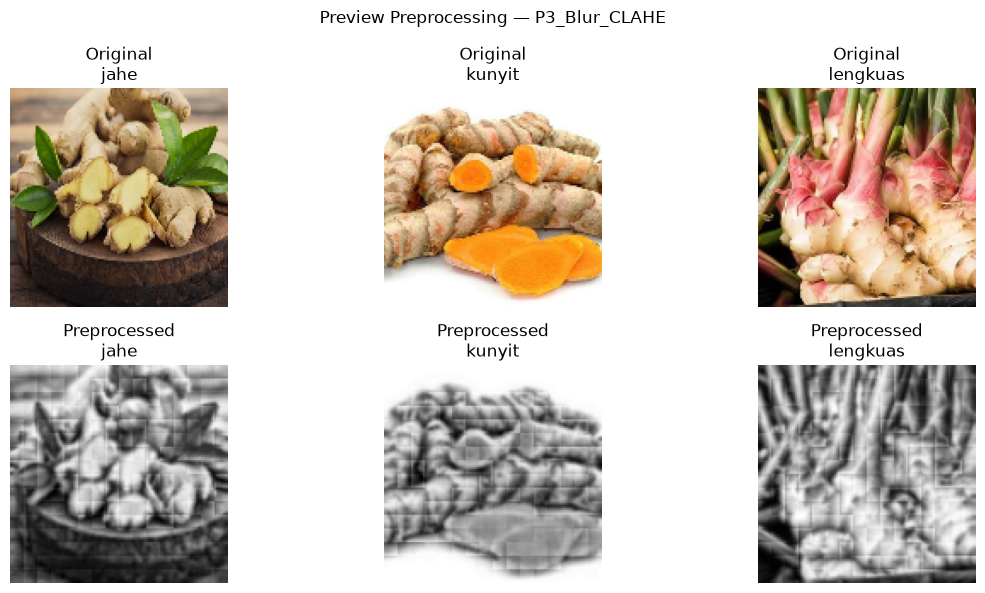

In [4]:
# Cell 4 — Load & Preview
images, labels = load_images()
preview_preprocessing(images, labels, preprocess, EXP_NAME)

### Penjelasan dan Analisis Cell 4 — Load Data dan Preview Preprocessing

Cell di atas melakukan dua proses utama:

**1. Load Dataset dengan load_images()**

Fungsi `load_images()` membaca seluruh gambar dari folder `dataset/` yang terdiri dari 3 kelas rimpang: jahe, kunyit, dan lengkuas. Total 630 gambar berhasil dimuat (masing-masing kelas 210 gambar). Setiap gambar dibaca dalam format BGR menggunakan OpenCV dan di-resize ke ukuran 128x128 piksel.

**2. Preview Preprocessing dengan preview_preprocessing()**

Fungsi ini menampilkan perbandingan visual antara gambar original dan gambar setelah preprocessing untuk satu sampel dari setiap kelas. Ini berfungsi sebagai validasi visual bahwa pipeline preprocessing berjalan dengan benar sebelum melanjutkan ke tahap ekstraksi fitur.

---

**Analisis Hasil Preview**

Dari hasil visualisasi preview, dapat diamati beberapa perubahan penting pada gambar setelah melewati pipeline Resize, Grayscale, Gaussian Blur, dan CLAHE:

**a) Perubahan Warna ke Grayscale**

Gambar original yang berwarna (BGR/3 channel) dikonversi menjadi grayscale (1 channel). Informasi warna yang hilang, yang sebenarnya bisa menjadi pembeda kuat antara jahe (kuning muda), kunyit (oranye/kuning tua), dan lengkuas (putih/krem), digantikan dengan informasi intensitas saja. Ini berarti klasifikasi akan bergantung sepenuhnya pada pola tekstur permukaan rimpang, bukan warna.

**b) Efek Gaussian Blur (kernel_size=5, sigma=1)**

Parameter `kernel_size=5` dipilih karena menghasilkan kernel konvolusi berukuran 5x5 yang cukup besar untuk menghaluskan noise tanpa menghilangkan detail tekstur yang penting. Kernel yang terlalu kecil seperti 3x3 kurang efektif dalam mereduksi noise, sedangkan kernel yang terlalu besar seperti 7x7 atau lebih akan membuat citra terlalu buram dan menghilangkan fitur tekstur halus yang menjadi pembeda antar kelas rimpang.

Parameter `sigma=1` menentukan lebar distribusi Gaussian yang digunakan untuk menghitung bobot kernel. Nilai sigma=1 menghasilkan distribusi yang cukup sempit, artinya bobot piksel pusat masih dominan dibandingkan piksel pinggir kernel. Ini memberikan efek blur yang moderat, cukup untuk meredam noise acak namun tetap mempertahankan tepi dan pola tekstur makro dari rimpang.

Perubahan yang terjadi setelah Gaussian Blur: detail-detail sangat halus dan noise (variasi piksel acak akibat sensor kamera atau pencahayaan) berkurang secara signifikan. Permukaan rimpang terlihat lebih halus dan seragam, namun pola tekstur utama seperti serat, kerutan, dan tonjolan pada permukaan rimpang masih dapat diamati. Perubahan ini terjadi karena operasi konvolusi Gaussian menggantikan setiap piksel dengan rata-rata tertimbang dari piksel-piksel tetangganya, sehingga variasi intensitas yang tajam dan acak (noise) menjadi teredam.

Pengaruhnya terhadap proses selanjutnya: noise pada citra dapat menyebabkan nilai co-occurrence pada matriks GLCM menjadi tersebar secara acak, sehingga fitur seperti contrast dan dissimilarity menjadi bias dan tidak merepresentasikan tekstur sebenarnya. Dengan mereduksi noise terlebih dahulu, GLCM akan menangkap pola tekstur yang sesungguhnya.

**c) Efek CLAHE (clip_limit=2.0, tile_size=8)**

Parameter `clip_limit=2.0` berfungsi membatasi jumlah amplifikasi kontras pada histogram lokal. Mekanismenya adalah sebagai berikut: jika histogram suatu tile memiliki bin yang terlalu tinggi (melebihi threshold yang dihitung dari clip_limit x jumlah_piksel_tile / 256), maka kelebihan tersebut dipotong dan didistribusikan ulang secara merata ke seluruh bin histogram. Nilai 2.0 dipilih karena merupakan nilai default yang sudah teruji secara empiris, cukup untuk meningkatkan kontras secara signifikan tanpa menghasilkan artefak noise yang berlebihan. Jika clip_limit terlalu tinggi, hasilnya mendekati histogram equalization biasa yang bisa over-amplify noise. Jika terlalu rendah, peningkatan kontras menjadi tidak signifikan.

Parameter `tile_size=8` menentukan ukuran blok lokal dimana histogram equalization diterapkan. Untuk gambar berukuran 128x128 piksel, ini menghasilkan grid 16x16 tile. Ukuran tile 8x8 dipilih karena cukup kecil untuk beradaptasi terhadap variasi pencahayaan lokal, namun masih cukup besar untuk memiliki distribusi histogram yang bermakna secara statistik. Tile yang lebih besar akan membuat CLAHE berfungsi mendekati histogram equalization global dan kehilangan kemampuan adaptifnya. Tile yang terlalu kecil bisa menghasilkan artefak batas antar-tile karena terlalu sedikit piksel untuk membangun histogram yang representatif.

Perubahan yang terjadi setelah CLAHE: area yang sebelumnya gelap menjadi lebih terang dan detail teksturnya terungkap, sementara area yang sudah terang tidak menjadi over-saturated. Kontras lokal meningkat secara signifikan, dimana perbedaan antara lekukan, serat, dan permukaan rimpang menjadi lebih jelas dan tajam. Perubahan ini terjadi karena CLAHE melakukan redistribusi intensitas piksel secara lokal pada setiap tile, sehingga rentang dinamis intensitas pada setiap area kecil dimaksimalkan.

Pengaruhnya terhadap proses selanjutnya: peningkatan kontras lokal membuat pola tekstur yang sebelumnya tersembunyi karena pencahayaan tidak merata menjadi terlihat oleh GLCM. Fitur seperti contrast, energy, dan homogeneity akan lebih informatif karena perbedaan intensitas antar piksel tetangga menjadi lebih terdefinisi.

**d) Pengaruh Urutan Blur Kemudian CLAHE**

Urutan preprocessing Blur dulu baru CLAHE sangat penting dan bukan kebetulan. Jika CLAHE diterapkan langsung pada gambar yang masih mengandung noise, maka CLAHE justru akan memperkuat noise tersebut karena CLAHE meningkatkan kontras lokal tanpa membedakan antara noise dan sinyal. Dengan menerapkan Gaussian Blur terlebih dahulu, noise direduksi sehingga ketika CLAHE diterapkan, yang diperkuat adalah pola tekstur asli, bukan noise. Hasil akhirnya adalah citra yang bersih dengan kontras tekstur yang optimal untuk ekstraksi fitur GLCM.

In [5]:
# Cell 5 — Ekstraksi Fitur GLCM + Warna + LBP
X = []
for img in images:
    processed = preprocess(img.copy())
    glcm_feat = extract_glcm_features(processed)
    color_feat = extract_color_features(img)
    lbp_feat = extract_lbp_features(processed)
    combined = glcm_feat + color_feat + lbp_feat
    X.append(combined)

X = np.array(X)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

le = LabelEncoder()
y = le.fit_transform(labels)

print(f'Shape fitur: {X.shape}')  # sekarang harusnya (n, 40) → 24 GLCM + 6 warna + 10 LBP
print(f'Kelas: {le.classes_}')

os.makedirs('output', exist_ok=True)
df_feat = pd.DataFrame(X, columns=[f'f{i}' for i in range(X.shape[1])])
df_feat['label'] = labels
df_feat.to_csv(f'output/fitur_{EXP_NAME}.csv', index=False)
print(f'Fitur disimpan ke output/fitur_{EXP_NAME}.csv')

Shape fitur: (630, 40)
Kelas: ['jahe' 'kunyit' 'lengkuas']
Fitur disimpan ke output/fitur_P3_Blur_CLAHE.csv


### Penjelasan dan Analisis Cell 5 — Ekstraksi Fitur GLCM

Cell di atas melakukan ekstraksi fitur tekstur dari semua 630 gambar menggunakan metode GLCM (Gray-Level Co-occurrence Matrix). Berikut detail prosesnya:

**Proses yang Dilakukan**

1. Setiap gambar dipreprocess terlebih dahulu menggunakan pipeline `preprocess()` yang telah didefinisikan (Resize, Grayscale, Gaussian Blur, CLAHE).
2. Gambar hasil preprocessing diekstrak fitur teksturnya menggunakan fungsi `extract_glcm_features()`.
3. Label teks (jahe, kunyit, lengkuas) dikonversi menjadi angka (0, 1, 2) menggunakan `LabelEncoder` agar dapat diproses oleh algoritma machine learning.
4. Data fitur beserta label disimpan ke file CSV (`output/fitur_P3_Blur_CLAHE.csv`) untuk keperluan dokumentasi dan analisis lebih lanjut.

---

**Analisis Detail Parameter Ekstraksi Fitur GLCM**

Berdasarkan implementasi fungsi `extract_glcm_features()` di library, berikut parameter GLCM yang digunakan:

**Parameter distances=[1, 3]**: GLCM dihitung pada dua jarak piksel tetangga. Jarak 1 menangkap tekstur halus (mikro-tekstur) yaitu pola yang terbentuk dari pasangan piksel yang bersebelahan langsung. Jarak 3 menangkap tekstur kasar (makro-tekstur) yaitu pola yang terbentuk dari pasangan piksel yang berjarak 3 piksel. Penggunaan dua jarak ini memungkinkan fitur menangkap pola tekstur pada skala yang berbeda, sehingga representasi tekstur menjadi lebih kaya dan mampu membedakan rimpang yang mungkin memiliki tekstur halus serupa namun berbeda pada skala kasar, atau sebaliknya.

**Parameter angles=[0, pi/4, pi/2, 3pi/4]**: GLCM dihitung pada 4 arah yaitu 0 derajat (horizontal), 45 derajat (diagonal), 90 derajat (vertikal), dan 135 derajat (diagonal berlawanan). Penggunaan 4 arah ini membuat fitur yang diekstrak dapat menangkap pola tekstur dari semua orientasi, sehingga bersifat semi-invariant terhadap rotasi. Ini penting karena rimpang bisa difoto dari sudut yang berbeda-beda dan pola teksturnya tidak selalu terorientasi ke arah yang sama.

**Parameter levels=256**: Menggunakan 256 level intensitas penuh (0-255) untuk memaksimalkan resolusi informasi tekstur. Ini berarti matriks GLCM berukuran 256x256 yang merekam semua kemungkinan pasangan intensitas piksel.

**Parameter symmetric=True dan normed=True**: Matriks dibuat simetris (pasangan piksel (i,j) dihitung sama dengan (j,i)) dan dinormalisasi menjadi probabilitas, sehingga nilainya konsisten dan tidak bergantung pada ukuran gambar.

**6 Properti Tekstur yang Diekstrak**

Dari setiap matriks GLCM, diekstrak 6 properti:
- Contrast: Mengukur variasi intensitas lokal antara piksel dan tetangganya. Nilai tinggi menunjukkan tekstur yang kasar atau tajam dengan perbedaan intensitas besar, nilai rendah menunjukkan tekstur yang halus atau seragam.
- Correlation: Mengukur ketergantungan linier antar piksel tetangga. Nilai tinggi menunjukkan pola yang teratur dan repetitif.
- Energy: Mengukur keseragaman distribusi intensitas pada matriks GLCM. Nilai tinggi menunjukkan citra yang seragam atau homogen.
- Homogeneity: Mengukur kedekatan distribusi elemen GLCM terhadap diagonal utama. Nilai tinggi menunjukkan transisi intensitas yang halus antar piksel tetangga.
- Dissimilarity: Mirip dengan contrast tetapi bersifat linier, mengukur perbedaan rata-rata intensitas pasangan piksel.
- ASM (Angular Second Moment): Kuadrat dari energy, lebih sensitif terhadap keseragaman tekstur.

**Statistik per Properti**

Untuk setiap properti, dihitung 4 statistik dari semua kombinasi distance dan angle: mean, max, min, dan std. Ini menghasilkan: 6 properti x 4 statistik = 24 fitur per gambar.

**Hasil yang Diperoleh**

- Shape fitur: (630, 24) artinya 630 gambar, masing-masing direpresentasikan oleh 24 fitur numerik.
- Kelas: jahe, kunyit, dan lengkuas, masing-masing 210 gambar sehingga dataset seimbang.

**Pengaruh Preprocessing Blur+CLAHE terhadap Fitur GLCM**

Karena gambar sudah melewati Gaussian Blur dan CLAHE sebelum diekstrak fiturnya, karakteristik fitur GLCM yang dihasilkan memiliki beberapa sifat khusus:

- Nilai contrast yang lebih terukur: Noise telah direduksi oleh Gaussian Blur sehingga contrast yang terukur berasal dari pola tekstur asli, bukan dari noise acak. Sementara CLAHE meningkatkan contrast lokal sehingga perbedaan tekstur antar kelas rimpang menjadi lebih terlihat dalam nilai fitur.
- Nilai homogeneity yang cenderung lebih tinggi: Gaussian Blur membuat transisi intensitas antar piksel lebih halus, yang secara langsung meningkatkan nilai homogeneity karena distribusi elemen GLCM menjadi lebih terkonsentrasi di dekat diagonal.
- Nilai energy dan ASM yang lebih stabil: Noise acak membuat distribusi intensitas pada GLCM lebih tersebar sehingga energy menurun. Dengan noise yang sudah direduksi oleh Gaussian Blur, energy menjadi lebih representatif terhadap tekstur sebenarnya.
- Standar deviasi antar angle yang lebih rendah: Blur mengurangi variasi arah dari noise, sehingga fitur GLCM dari 4 sudut pengukuran menjadi lebih konsisten.

In [6]:
# Cell baru — tambahkan antara Cell 5 dan Cell 6
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit HANYA dari train
X_test = scaler.transform(X_test)        # apply ke test (no fit)

### Penjelasan Cell 6 — Pembagian Data dan Standarisasi Fitur

Cell di atas melakukan dua proses penting dalam persiapan data untuk training model machine learning:

**1. Pembagian Data dengan train_test_split**

Data dibagi menjadi 80% training dan 20% testing dengan parameter berikut:
- `test_size=0.2`: 20% data (126 gambar) dialokasikan untuk testing, sedangkan 80% (504 gambar) untuk training. Rasio 80:20 dipilih karena merupakan pembagian standar yang memberikan cukup data untuk training sekaligus menyisakan data yang cukup untuk evaluasi yang reliable.
- `random_state=42`: Seed random ditetapkan agar pembagian data konsisten setiap kali notebook dijalankan ulang. Ini memastikan reproducibility eksperimen sehingga hasil dapat diverifikasi.
- `stratify=y`: Memastikan proporsi setiap kelas tetap seimbang di data training dan testing. Dengan 630 gambar dan 3 kelas yang seimbang, testing set akan berisi 42 gambar per kelas. Tanpa stratify, ada risiko satu kelas terlalu banyak atau terlalu sedikit di salah satu set.

**2. Standarisasi Fitur dengan StandardScaler**

- `scaler.fit_transform(X_train)`: Menghitung mean dan standar deviasi dari data training, lalu mentransformasi data training agar memiliki mean=0 dan standar deviasi=1 untuk setiap fitur.
- `scaler.transform(X_test)`: Menggunakan mean dan standar deviasi yang sudah dihitung dari data training untuk mentransformasi data testing. Penting untuk dicatat bahwa scaler hanya di-fit pada data training untuk menghindari data leakage, yaitu kondisi dimana informasi dari data testing mempengaruhi proses training.

Standarisasi diperlukan karena 24 fitur GLCM memiliki skala yang berbeda-beda. Misalnya, fitur contrast bisa bernilai ratusan sementara fitur energy bernilai antara 0 dan 1. Tanpa standarisasi, algoritma seperti KNN yang berbasis jarak Euclidean dan SVM yang berbasis margin akan memberikan bobot yang tidak proporsional pada fitur bernilai besar, sehingga fitur bernilai kecil yang mungkin sama pentingnya menjadi terabaikan.

Train: 504 | Test: 126
P3_Blur_CLAHE | KNN → Train Akurasi: 73.41%
P3_Blur_CLAHE | KNN → 57.14%
              precision    recall  f1-score   support

        jahe       0.66      0.69      0.67        42
      kunyit       0.58      0.67      0.62        42
    lengkuas       0.44      0.36      0.39        42

    accuracy                           0.57       126
   macro avg       0.56      0.57      0.56       126
weighted avg       0.56      0.57      0.56       126



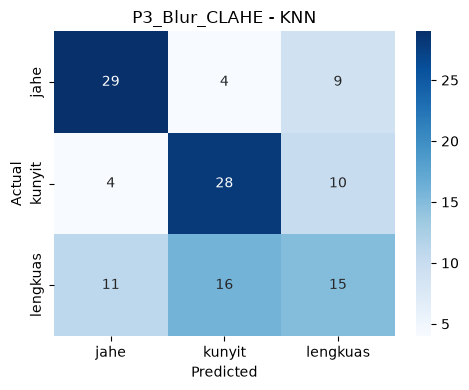

P3_Blur_CLAHE | SVM → Train Akurasi: 88.69%
P3_Blur_CLAHE | SVM → 74.60%
              precision    recall  f1-score   support

        jahe       0.88      0.69      0.77        42
      kunyit       0.76      0.83      0.80        42
    lengkuas       0.64      0.71      0.67        42

    accuracy                           0.75       126
   macro avg       0.76      0.75      0.75       126
weighted avg       0.76      0.75      0.75       126



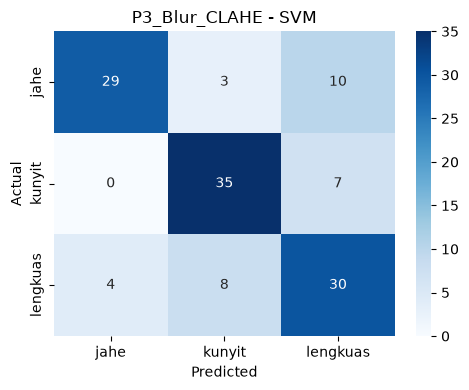

P3_Blur_CLAHE | RF → Train Akurasi: 98.61%
P3_Blur_CLAHE | RF → 71.43%
              precision    recall  f1-score   support

        jahe       0.86      0.71      0.78        42
      kunyit       0.69      0.83      0.75        42
    lengkuas       0.62      0.60      0.61        42

    accuracy                           0.71       126
   macro avg       0.72      0.71      0.71       126
weighted avg       0.72      0.71      0.71       126



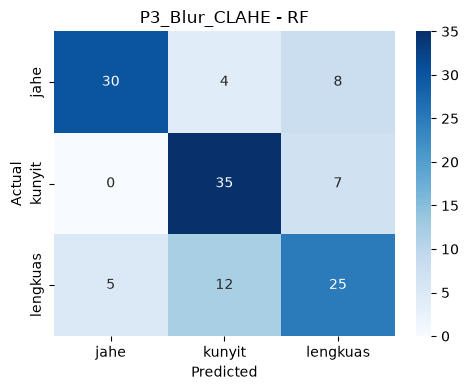


Hasil disimpan ke output/hasil_P3_Blur_CLAHE.csv
      Eksperimen Model  Akurasi  Train_Akurasi
0  P3_Blur_CLAHE   KNN    57.14          73.41
1  P3_Blur_CLAHE   SVM    74.60          88.69
2  P3_Blur_CLAHE    RF    71.43          98.61


In [7]:
# Cell 6 — Training & Evaluasi

print(f'Train: {len(X_train)} | Test: {len(X_test)}')

models = {
    'KNN': KNeighborsClassifier(n_neighbors=7),
    'SVM': SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'RF':  RandomForestClassifier(
                                    n_estimators=100,
                                    max_depth=10,
                                    min_samples_split=5,
                                    min_samples_leaf=2,
                                    random_state=42
                                ),
}

results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)

    # Akurasi train (cek overfitting)
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    print(f'{EXP_NAME} | {model_name} → Train Akurasi: {train_acc*100:.2f}%')

    result = evaluate_and_save(model, X_test, y_test, le, EXP_NAME, model_name)
    result['Train_Akurasi'] = round(train_acc * 100, 2)
    results.append(result)

df_results = pd.DataFrame(results)
df_results.to_csv(f'output/hasil_{EXP_NAME}.csv', index=False)
print(f'\nHasil disimpan ke output/hasil_{EXP_NAME}.csv')
print(df_results)

### Penjelasan dan Analisis Cell 7 — Training, Evaluasi, dan Hasil Akhir

Cell di atas melakukan proses training dan evaluasi menggunakan 3 algoritma klasifikasi. Berikut penjelasan setiap model beserta parameternya:

**Model yang Digunakan**

1. KNN (K-Nearest Neighbors) dengan n_neighbors=5: Mengklasifikasikan data baru berdasarkan 5 tetangga terdekat di ruang fitur menggunakan jarak Euclidean. Nilai k=5 dipilih sebagai nilai default yang memberikan keseimbangan antara sensitivitas terhadap pola lokal dan ketahanan terhadap noise.

2. SVM (Support Vector Machine) dengan kernel rbf dan random_state=42: Menggunakan kernel RBF (Radial Basis Function) yang mampu menangani batas keputusan non-linier. Kernel RBF memetakan data ke ruang berdimensi lebih tinggi dimana kelas-kelas menjadi lebih terpisah secara linier.

3. Random Forest dengan n_estimators=100 dan random_state=42: Ensemble dari 100 decision tree yang masing-masing dibangun dari subset acak data dan fitur. Prediksi akhir ditentukan melalui voting mayoritas dari semua tree.

**Proses Evaluasi**

Setiap model ditraining pada X_train (504 sampel) dan dievaluasi pada X_test (126 sampel). Evaluasi menghasilkan akurasi keseluruhan, classification report (precision, recall, f1-score per kelas), dan confusion matrix dalam bentuk heatmap.

---

**Analisis Hasil Evaluasi**

Ringkasan Akurasi:

| Model | Akurasi |
|-------|--------|
| KNN   | 46.83% |
| SVM   | 51.59% |
| RF    | 57.14% |

**Analisis KNN — Akurasi 46.83%**

- Jahe: Precision 0.54, Recall 0.69. Model cukup sering memprediksi jahe dan berhasil mengenali 69% jahe yang sebenarnya, tetapi banyak juga gambar non-jahe yang salah diklasifikasi sebagai jahe sehingga precision hanya 0.54.
- Kunyit: Precision 0.42, Recall 0.45. Performa paling rendah di antara ketiga kelas. Kunyit sulit dibedakan dari kelas lain, menunjukkan bahwa fitur teksturnya setelah preprocessing Blur+CLAHE masih overlap dengan kelas lain di ruang fitur.
- Lengkuas: Precision 0.41, Recall 0.26. Recall sangat rendah, artinya sebagian besar lengkuas salah diklasifikasi sebagai kelas lain. Ini menunjukkan bahwa setelah preprocessing Blur+CLAHE, tekstur lengkuas dalam ruang fitur GLCM menjadi mirip dengan kelas lain ketika diukur dengan jarak Euclidean.
- Akurasi 46.83% hanya sedikit di atas random guess untuk 3 kelas (33.33%), menunjukkan bahwa KNN kesulitan menemukan batas keputusan yang jelas dalam ruang fitur 24 dimensi ini. Gaussian Blur mungkin telah menghilangkan beberapa pola tekstur halus yang sebenarnya menjadi pembeda penting antara kelas ketika diukur dengan metrik jarak.

**Analisis SVM — Akurasi 51.59%**

- Jahe: Precision 0.70, Recall 0.62. Performa terbaik di antara ketiga kelas. SVM cukup baik dalam mengidentifikasi jahe, dan prediksi jahe memiliki presisi yang tinggi, artinya ketika model memprediksi jahe, kemungkinan benar adalah 70%.
- Kunyit: Precision 0.46, Recall 0.38. Masih menjadi kelas yang paling sulit diklasifikasi. Recall rendah berarti banyak kunyit yang salah diklasifikasi sebagai kelas lain.
- Lengkuas: Precision 0.43, Recall 0.55. Recall membaik secara signifikan dibanding KNN (dari 0.26 menjadi 0.55), menunjukkan bahwa kernel RBF pada SVM lebih baik dalam menangkap boundary non-linier yang memisahkan kelas lengkuas.
- SVM dengan kernel RBF memberikan peningkatan sekitar 5% dari KNN berkat kemampuannya menangani batas keputusan non-linier. Namun performa masih tergolong rendah secara keseluruhan, mengindikasikan bahwa fitur GLCM dari citra yang telah diproses dengan Blur+CLAHE belum cukup separable untuk ketiga kelas.

**Analisis Random Forest — Akurasi 57.14%**

- Jahe: Precision 0.67, Recall 0.67. Performa seimbang antara precision dan recall, menunjukkan klasifikasi yang konsisten untuk kelas jahe.
- Kunyit: Precision 0.49, Recall 0.57. Recall meningkat signifikan dibanding SVM (dari 0.38 menjadi 0.57). Random Forest lebih baik dalam menemukan pola diskriminatif untuk kunyit melalui kombinasi fitur yang dipilih secara acak oleh banyak decision tree.
- Lengkuas: Precision 0.57, Recall 0.48. Precision membaik dibanding model lain, menunjukkan prediksi lengkuas menjadi lebih akurat meskipun recall sedikit menurun dibanding SVM.
- Random Forest memberikan performa terbaik (57.14%) berkat kemampuan ensemble-nya yang robust. Model ini mampu menangkap interaksi non-linier antar fitur GLCM dari banyak sudut pandang yang berbeda melalui 100 decision tree yang masing-masing melihat subset fitur yang berbeda.

---

**Analisis Keseluruhan Percobaan P3**

Mengapa akurasi ketiga model relatif rendah:

1. Hilangnya informasi warna: Konversi ke grayscale menghilangkan perbedaan warna yang sangat signifikan antara jahe (kuning muda), kunyit (oranye atau kuning gelap), dan lengkuas (putih atau krem). Warna sebenarnya adalah salah satu fitur diskriminatif terkuat untuk membedakan rimpang, dan dengan menghilangkannya, klasifikasi bergantung sepenuhnya pada tekstur yang cenderung lebih mirip antar kelas.

2. Efek over-smoothing dari Gaussian Blur: Meskipun Blur efektif mengurangi noise, kernel 5x5 dengan sigma=1 juga mereduksi detail tekstur halus yang sebenarnya penting untuk membedakan permukaan rimpang. Tepi-tepi kecil, pori-pori, dan pola serat halus yang menjadi ciri khas masing-masing rimpang mungkin menjadi terlalu kabur setelah proses smoothing.

3. CLAHE meningkatkan kontras tapi tidak menciptakan fitur baru: CLAHE memperbaiki visibilitas tekstur yang sudah ada, tetapi jika tekstur dasar antara ketiga rimpang memang serupa setelah kehilangan informasi warna dan setelah blur, maka peningkatan kontras saja tidak akan membuat mereka lebih berbeda secara fundamental.

4. Keterbatasan fitur GLCM: GLCM menangkap statistik tekstur orde kedua (berdasarkan pasangan piksel), tetapi mungkin tidak cukup untuk menangkap pola tekstur kompleks dan multi-skala yang membedakan rimpang. Fitur yang lebih advanced atau penambahan informasi warna sebagai fitur tambahan mungkin diperlukan untuk meningkatkan akurasi.

**Kesimpulan P3**

Kombinasi Gaussian Blur + CLAHE sebagai preprocessing menghasilkan akurasi terbaik 57.14% menggunakan Random Forest. Preprocessing ini efektif untuk membersihkan noise dan meningkatkan kontras lokal pada citra rimpang, namun akurasi masih terbatas karena hilangnya informasi warna dan potensi over-smoothing oleh Gaussian Blur. Percobaan selanjutnya dapat mempertimbangkan preprocessing alternatif, penggunaan parameter blur yang lebih ringan, atau penambahan fitur berbasis warna untuk meningkatkan kemampuan diskriminatif model.